# 🌾 Smart Farm: Data Understanding & Exploratory Analysis

This notebook provides a comprehensive look into the three pillars of our agricultural data system:
1. **Plant Health & RAG Knowledge Base**: Disease classes, treatments, and safety intervals.
2. **Precision Irrigation**: Environmental factors, evapotranspiration, and water demand cycles.
3. **Livestock Management**: Biometrics, growth tracking, and clinical health history.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import re
import os
from datetime import datetime

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## 1. Pillar 1: Plant Health & RAG Baseline
Establishing the factual foundation for disease detection and treatment recommendations.

Total Disease Classes in CSV: 17


,Crop,Disease,Organic_Treatment,Chemical_Treatment,Dosage,PHI,Expert_Notes,Cultural_Control
0,Apple,Apple Scab (Venturia inaequalis),Sulfur or Potassium Bicarbonate sprays.,"Captan, Myclobutanil (Immunox), Flint.",Captan 80 WDG: 2.5-5.0 lbs/acre. Flint: 2 oz/a...,0-14 days,Primary infection occurs during spring rains. ...,Flail mow leaf litter in autumn to speed up de...
1,Apple,Black Rot (Diplodia seriata),"Copper based products, Lime-sulfur.","Mancozeb (Dithane), Captan, Thiophanate-methyl.",Dithane M45: 3 lbs/acre. Captan: 2.5 lbs/acre.,0-7 days,Commonly causes 'frog-eye' leaf spot. Overwint...,Prune out dead wood and remove 'mummies' (shri...
2,Apple,Cedar Apple Rust (Gymnosporangium),Limited success with Sulfur. Focus on resistan...,"Myclobutanil (Immunox), Chlorothalonil, Mancozeb.",Immunox: 4-8 fl oz/acre. Mancozeb: 3 lbs/acre.,14-77 days (check label for specific timing),Requires alternate host (Juniper/Red Cedar). D...,Remove galls from nearby juniper trees in earl...
3,Grape,Black Rot (Guignardia bidwellii),Copper or Sulfur (can be phytotoxic).,"Myclobutanil (Rally), Mancozeb, Elite.",Rally: 3-5 oz/acre. Mancozeb: 3-4 lbs/acre.,"14 days (Rally), 66 days (Mancozeb).",Most critical spray period is pre-bloom throug...,Winter pruning of mummies is mandatory for con...
4,Grape,Esca (Black Measles),Trichoderma species (Bio-control for pruning w...,No direct cure for established infection. Vect...,Pruning sealant (Vitiseal) immediately after c...,NaN,Fungal complex entering through pruning wounds...,Disinfect tools between vines. Protect large p...


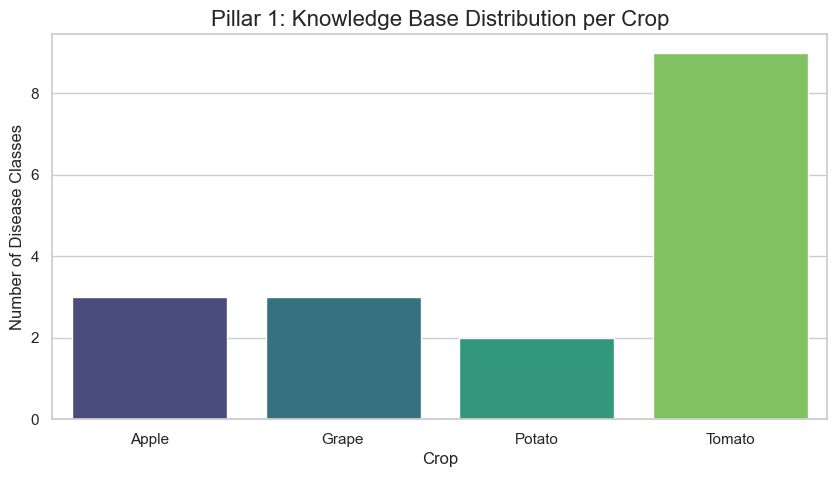

In [ ]:
file_path = 'Data/treatment2/treatment_2.csv'
if os.path.exists(file_path):
    df_rag = pd.read_csv(file_path)
    print(f"Total Disease Classes in CSV: {len(df_rag)}")
    display(df_rag.head())

    # Visualize Disease Distribution per Crop
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_rag, x='Crop', hue='Crop', palette='viridis', legend=False)
    plt.title('Pillar 1: Knowledge Base Distribution per Crop')
    plt.ylabel('Number of Disease Classes')
    plt.show()
else:
    print(f"Warning: {file_path} not found.")

**Interpretation:**
This distribution indicates which crops have the most comprehensive treatment documentation. A high count for a specific crop suggests a more mature RAG (Retrieval-Augmented Generation) system, while lower counts might highlight areas where further agronomic research and documentation are required to support the AI advisor.

### RAG Source Document & Image Dataset Analysis
Beyond the metadata, we analyze the raw source contents and the image libraries used for model training.

--- RAG Source Document Analysis ---


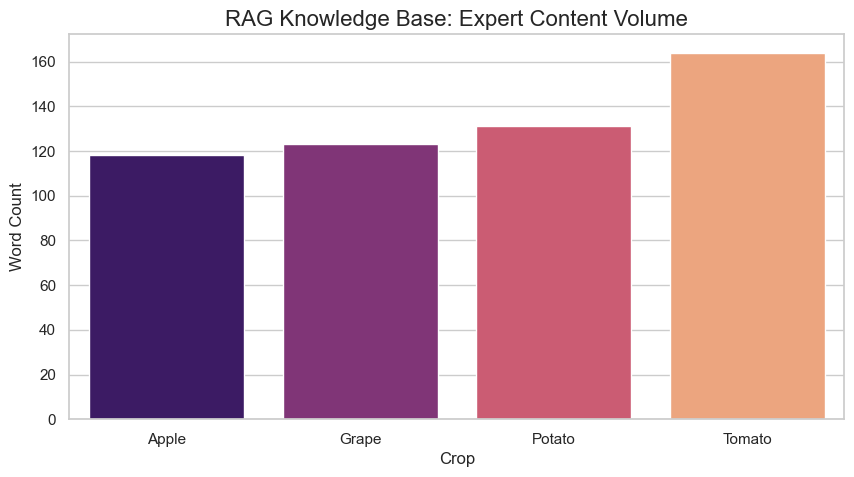


--- Crop Disease Image Dataset Analysis ---
Total Images in Dataset: 17155


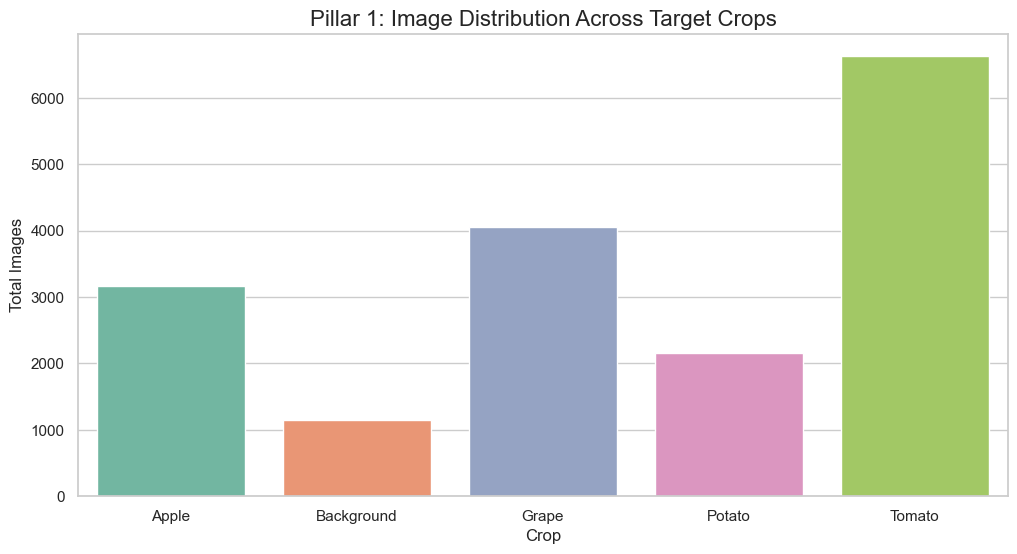

In [ ]:
# 1. RAG Source Document Analysis
print("--- RAG Source Document Analysis ---")
rag_dir = 'Data/treatment2'
if os.path.exists(rag_dir):
    manuals = [f for f in os.listdir(rag_dir) if f.endswith('_manual.txt')]
    rag_stats = []
    for manual in manuals:
        with open(os.path.join(rag_dir, manual), 'r', encoding='utf-8') as f:
            content = f.read()
            word_count = len(content.split())
            crop = manual.replace('_expert_manual.txt', '').capitalize()
            rag_stats.append({'Crop': crop, 'WordCount': word_count})

    if rag_stats:
        df_rag_stats = pd.DataFrame(rag_stats)
        plt.figure(figsize=(10, 5))
        sns.barplot(data=df_rag_stats, x='Crop', y='WordCount', hue='Crop', palette='magma', legend=False)
        plt.title('RAG Knowledge Base: Expert Content Volume')
        plt.ylabel('Word Count')
        plt.show()

# 2. Crop Disease Image Dataset Analysis
print("\n--- Crop Disease Image Dataset Analysis ---")
img_base_path = 'Data/Raw/Plant_leave_diseases_dataset_without_augmentation'
if os.path.exists(img_base_path):
    img_data = []
    for folder in os.listdir(img_base_path):
        folder_path = os.path.join(img_base_path, folder)
        if os.path.isdir(folder_path):
            count = len(os.listdir(folder_path))
            parts = folder.split('___')
            crop = parts[0] if len(parts) > 1 else 'Background'
            img_data.append({'Crop': crop, 'Class': folder, 'ImageCount': count})

    df_images = pd.DataFrame(img_data)
    print(f"Total Images in Dataset: {df_images['ImageCount'].sum()}")
    
    crop_counts = df_images.groupby('Crop')['ImageCount'].sum().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=crop_counts, x='Crop', y='ImageCount', hue='Crop', palette='Set2', legend=False)
    plt.title('Pillar 1: Image Distribution Across Target Crops')
    plt.ylabel('Total Images')
    plt.show()
else:
    print("Image dataset path not found.")

**Interpretation:**
The **Expert Content Volume** (word count) quantifies the depth of agronomic knowledge available for each crop class. Simultaneously, the **Image Distribution** identifies potential dataset imbalances. Significant imbalances—where some crops have thousands of images and others very few—can lead to biased model performance, guiding our future data collection and augmentation strategies.

### Defense Strategy Composition
How balanced is our knowledge base? Here we compare the availability of different protection methods (Organic, Chemical, and Cultural) across crops.

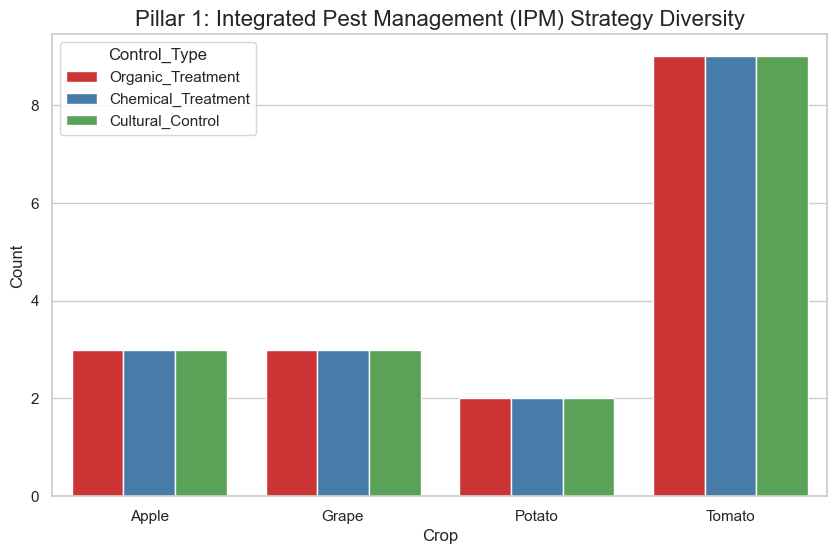

In [ ]:
if 'df_rag' in locals():
    # Count presence of different control types
    strat_df = df_rag.groupby('Crop')[['Organic_Treatment', 'Chemical_Treatment', 'Cultural_Control']].count().reset_index()
    strat_melted = strat_df.melt(id_vars='Crop', var_name='Control_Type', value_name='Count')
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=strat_melted, x='Crop', y='Count', hue='Control_Type', palette='Set1')
    plt.title('Pillar 1: Integrated Pest Management (IPM) Strategy Diversity')
    plt.show()

**Interpretation:**
This chart reveals the 'richness' of our IPM (Integrated Pest Management) strategy. If a crop has high values in all three categories, it indicates a highly resilient protection plan. Conversely, gaps in 'Organic' or 'Cultural' controls represent research opportunities to make the farm more sustainable.

### PHI (Pre-Harvest Interval) Analysis
PHI is a critical safety metric. High PHI values indicate treatments that must be administered long before harvest to ensure food safety.

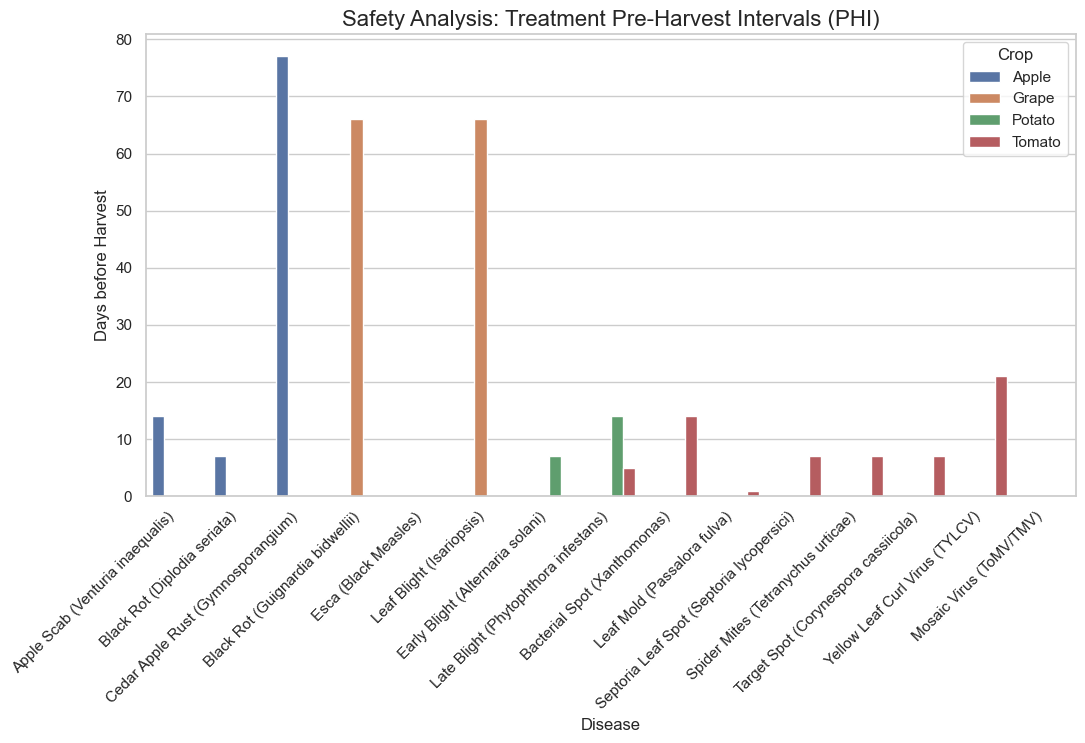

In [ ]:
def extract_phi(phi_str):
    if pd.isna(phi_str): return 0
    nums = re.findall(r'\d+', str(phi_str))
    return int(nums[-1]) if nums else 0

if 'df_rag' in locals():
    df_rag['PHI_Days'] = df_rag['PHI'].apply(extract_phi)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_rag, x='Disease', y='PHI_Days', hue='Crop')
    plt.xticks(rotation=45, ha='right')
    plt.title('Safety Analysis: Treatment Pre-Harvest Intervals (PHI)')
    plt.ylabel('Days before Harvest')
    plt.show()

**Interpretation:**
Pre-Harvest Intervals (PHI) are non-negotiable safety standards. The tallest bars represented here indicate treatments that require early intervention. This plot allows for strategic planning of pest control windows, ensuring that chemical residues are completely degraded by the time the product reaches the harvest stage.

## 2. Pillar 2: Precision Irrigation & Weather
Understanding the environmental drivers of water loss and soil moisture dynamics.

In [ ]:
# Load and clean the malformed Irrigation CSV
irr_path = 'Data/irrigation/irrigation_dataset_2_years(in).csv'
if os.path.exists(irr_path):
    with open(irr_path, 'r', encoding='utf-8') as f:
        raw_lines = f.readlines()

    cleaned_lines = []
    for line in raw_lines:
        l = line.strip()
        if l.startswith('"') and l.endswith('"'): l = l[1:-1]
        l = l.replace('""', '"')
        cleaned_lines.append(l)

    df_irrigation = pd.read_csv(io.StringIO('\n'.join(cleaned_lines)))

    # Convert numeric columns (fixing comma decimals)
    numeric_cols = [
        'soil_moisture_percent', 'air_temperature_celsius', 'relative_humidity_percent', 
        'wind_speed_mps', 'rainfall_mm', 'reference_evapotranspiration_ET0_mm', 
        'crop_coefficient_Kc', 'crop_evapotranspiration_ETc_mm', 
        'recommended_irrigation_mm', 'irrigation_duration_minutes'
    ]
    for col in numeric_cols:
        if col in df_irrigation.columns:
            df_irrigation[col] = df_irrigation[col].astype(str).str.replace(',', '.').astype(float)

    df_irrigation['date'] = pd.to_datetime(df_irrigation['date'])
    print("Irrigation Data Processed Successfully.")
    display(df_irrigation.head())
else:
    print("Irrigation file not found.")

Irrigation Data Processed Successfully.


,field_id,zone_id,crop_type,date,soil_moisture_percent,air_temperature_celsius,relative_humidity_percent,wind_speed_mps,rainfall_mm,reference_evapotranspiration_ET0_mm,crop_coefficient_Kc,crop_evapotranspiration_ETc_mm,recommended_irrigation_mm,irrigation_duration_minutes,irrigation_status
0,F_MED_01,Z1,Tomato,2022-01-01,78.2,14.8,82.7,5.8,0.0,3.1,1.18,3.66,0.0,0.0,Not Needed
1,F_MED_01,Z2,Grapes,2022-01-01,78.7,14.8,82.7,5.8,0.0,3.1,0.82,2.54,0.0,0.0,Not Needed
2,F_MED_01,Z3,Potato,2022-01-01,78.3,14.8,82.7,5.8,0.0,3.1,1.12,3.47,0.0,0.0,Not Needed
3,F_MED_01,Z4,Apple,2022-01-01,78.6,14.8,82.7,5.8,0.0,3.1,0.90,2.79,0.0,0.0,Not Needed
4,F_MED_01,Z1,Tomato,2022-01-02,77.3,14.5,74.0,2.3,0.0,1.6,1.11,1.78,0.0,0.0,Not Needed


### Environmental Interaction
Correlation analysis helps identify the primary drivers of irrigation demand.

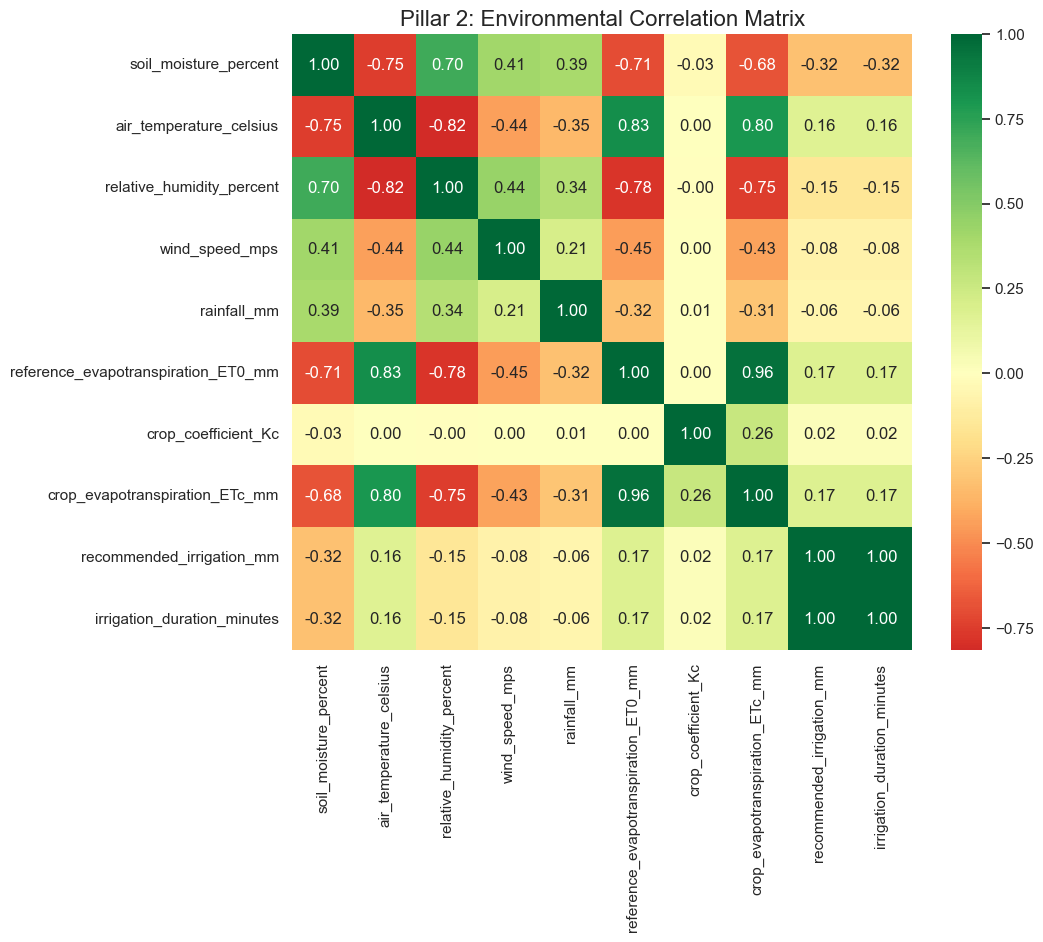

In [ ]:
if 'df_irrigation' in locals():
    plt.figure(figsize=(10, 8))
    # Select only numeric data for correlation
    numeric_df = df_irrigation.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
    plt.title('Pillar 2: Environmental Correlation Matrix')
    plt.show()

**Interpretation:**
The correlation matrix identifies the primary environmental drivers of water loss. Strong positive correlations between air temperature or wind speed and potential evapotranspiration (ET0) confirm that these factors are the dominant 'vampires' of soil moisture. This allows the irrigation model to proactively adjust pump activity based on local weather forecasts.

### The Climate Fingerprint
Understanding seasonality is vital for precision irrigation. Here we view the statistical distribution of temperature and humidity by month.

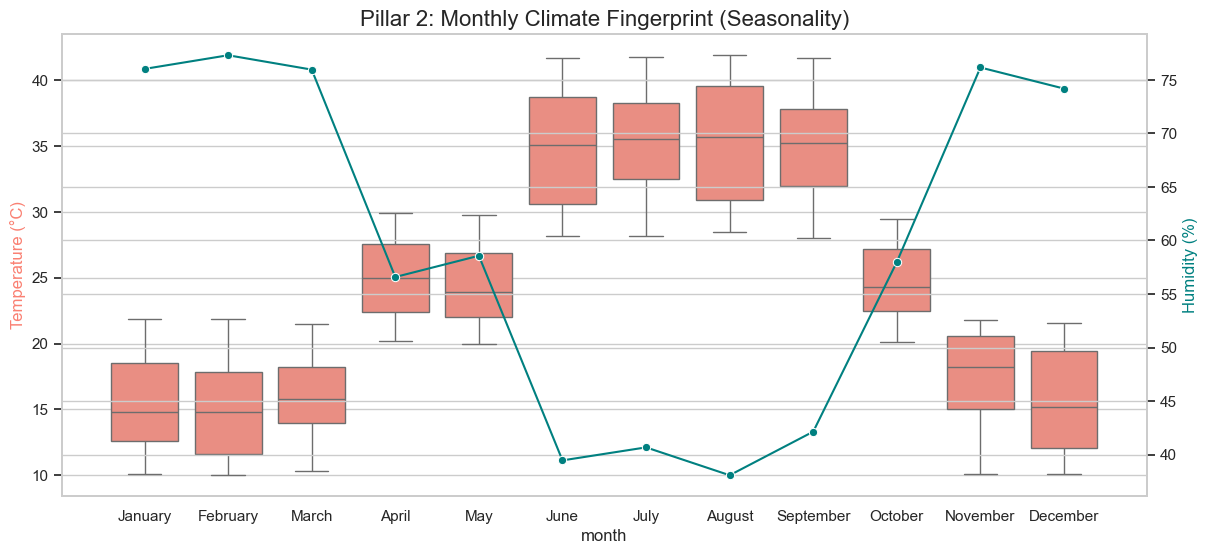

In [ ]:
if 'df_irrigation' in locals():
    df_irrigation['month'] = df_irrigation['date'].dt.month_name()
    
    fig, ax1 = plt.subplots(figsize=(14, 6))
    sns.boxplot(data=df_irrigation, x='month', y='air_temperature_celsius', color='salmon', ax=ax1)
    ax1.set_ylabel('Temperature (°C)', color='salmon')
    
    ax2 = ax1.twinx()
    sns.lineplot(data=df_irrigation, x='month', y='relative_humidity_percent', color='teal', errorbar=None, ax=ax2, marker='o')
    ax2.set_ylabel('Humidity (%)', color='teal')
    
    plt.title('Pillar 2: Monthly Climate Fingerprint (Seasonality)')
    plt.show()

**Interpretation:**
The boxplots show the 'comfort zone' of the environment. The relationship between the rising temperature boxes and the humidity line (Teal) tells us when the 'Vapor Pressure Deficit' is highest. This is the period of highest risk for plant transpiration stress and will correlate directly with irrigation demand.

### Supply vs. Demand: Rainfall and Irrigation
This plot shows how the system recommends irrigation when rainfall is insufficient.

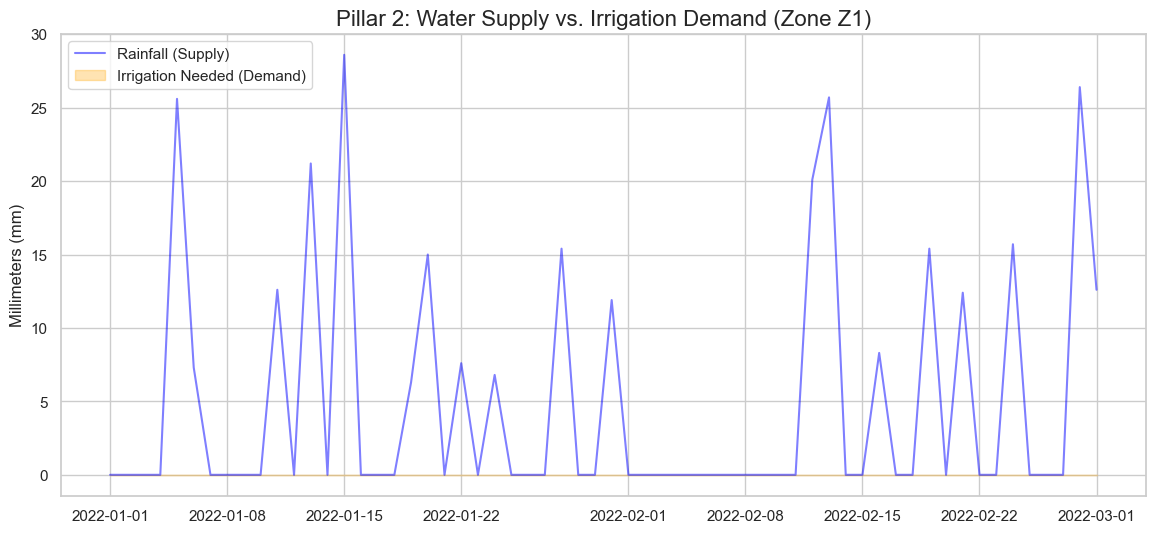

In [ ]:
if 'df_irrigation' in locals():
    df_z1 = df_irrigation[df_irrigation['zone_id'] == 'Z1'].head(60)
    plt.figure(figsize=(14, 6))
    plt.plot(df_z1['date'], df_z1['rainfall_mm'], label='Rainfall (Supply)', color='blue', alpha=0.5)
    plt.fill_between(df_z1['date'], df_z1['recommended_irrigation_mm'], color='orange', alpha=0.3, label='Irrigation Needed (Demand)')
    plt.title('Pillar 2: Water Supply vs. Irrigation Demand (Zone Z1)')
    plt.ylabel('Millimeters (mm)')
    plt.legend()
    plt.show()

**Interpretation:**
This 'Supply vs. Demand' area chart is the core operational dashboard. The blue spikes represent free water supply (rainfall), while the orange shaded regions highlight the 'Irrigation Deficit'. When rainfall is insufficient to cover the crop's water loss, the system triggers automated irrigation to keep the plant in its optimal growth zone.

## 3. Pillar 3: Livestock Bio-Metrics
Monitoring growth performance and clinical health status.

In [ ]:
sql_path = 'Data/Livestock/livestock_seed.sql'
if os.path.exists(sql_path):
    with open(sql_path, 'r', encoding='utf-8') as f:
        sql_text = f.read()

    # Use non-greedy and multi-part regex for robustness
    animals = re.findall(r"\('([a-f\d-]+)', '([\w-]+)', '(\w+)', '([\w\s]+)', '(\w+)', '([\d-]+)', '([\d-]+)', '(\w+)'\)", sql_text)
    df_animals = pd.DataFrame(animals, columns=['id', 'tag', 'species', 'breed', 'gender', 'birth_date', 'entry_date', 'status'])

    weights = re.findall(r"\('([a-f\d-]+)', ([\d\.]+), '([^']+)'\)", sql_text)
    df_weights = pd.DataFrame(weights, columns=['animal_id', 'weight', 'date'])
    df_weights['weight'] = df_weights['weight'].astype(float)
    df_weights['date'] = pd.to_datetime(df_weights['date'])

    health = re.findall(r"\('([a-f\d-]+)', ([\d\.]+), '([^']+)', '([^']+)', '([^']+)'\)", sql_text)
    df_health = pd.DataFrame(health, columns=['animal_id', 'temp', 'diagnosis', 'treatment', 'timestamp'])
    df_health['temp'] = df_health['temp'].astype(float)
    df_health['timestamp'] = pd.to_datetime(df_health['timestamp'])

    print(f"Parsed {len(df_animals)} animals, {len(df_weights)} weight records, and {len(df_health)} health records.")
else:
    print("Livestock SQL file not found.")

Parsed 250 animals, 2836 weight records, and 1109 health records.


### Health Diagnostics Breakdown
Analyzing the frequency of health conditions across the flock/herd.

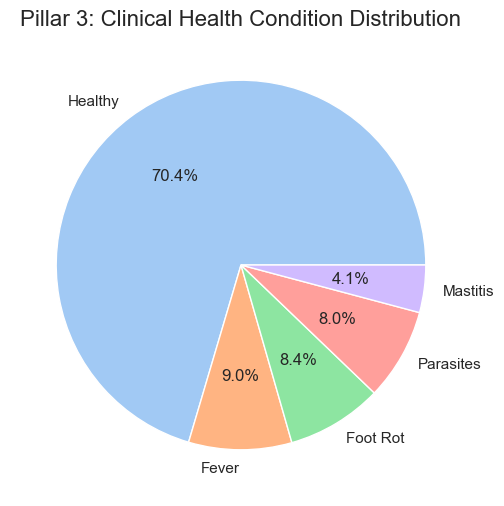

In [ ]:
if 'df_health' in locals():
    plt.figure(figsize=(10, 6))
    health_counts = df_health['diagnosis'].value_counts()
    plt.pie(health_counts, labels=health_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    plt.title('Pillar 3: Clinical Health Condition Distribution')
    plt.show()

**Interpretation:**
This clinical breakdown summarizes the overall health status of the herd/flock. While 'Healthy' should always be the majority, tracking the proportion of conditions like 'Parasites' or 'Fever' helps in assessing environmental stressors or the effectiveness of past treatments at the population level.

### Growth Trends: Weight Gain Analysis
Tracking the weight of the first 5 animals as a representation of growth velocity.

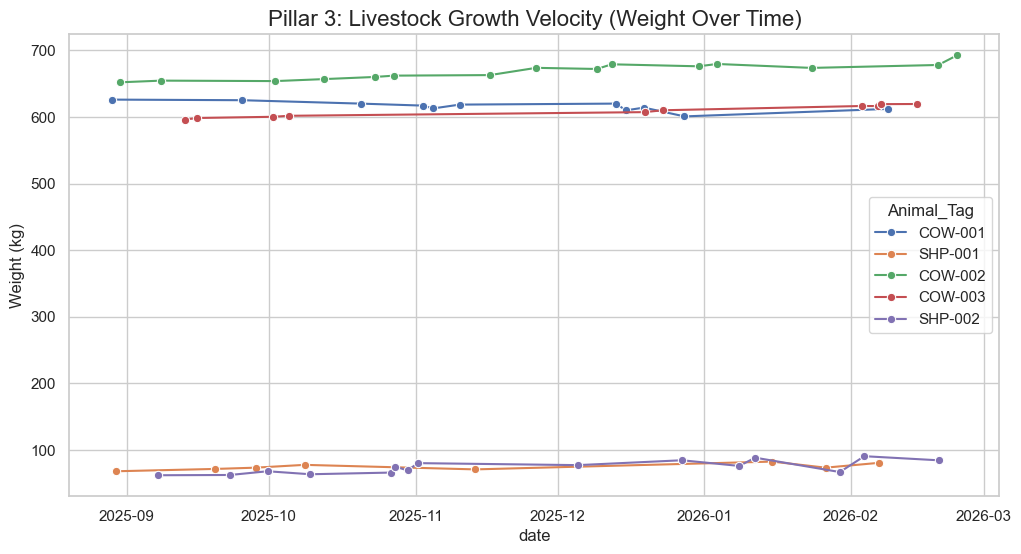

In [ ]:
if 'df_animals' in locals() and 'df_weights' in locals():
    sample_animal_ids = df_animals['id'].head(5).tolist()
    df_sample_weights = df_weights[df_weights['animal_id'].isin(sample_animal_ids)].copy()

    tag_map = df_animals.set_index('id')['tag'].to_dict()
    df_sample_weights['Animal_Tag'] = df_sample_weights['animal_id'].map(tag_map)

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_sample_weights, x='date', y='weight', hue='Animal_Tag', marker='o')
    plt.title('Pillar 3: Livestock Growth Velocity (Weight Over Time)')
    plt.ylabel('Weight (kg)')
    plt.show()

**Interpretation:**
Growth velocity is the ultimate indicator of livestock performance. These lines track individual weight gain over time. Consistent, parallel upward slopes indicate healthy development and successful nutrition programs, while any sudden flatlining or downward dip would trigger an automated clinical alert for that specific animal.

### Clinical Vital Signs Validation
Does a diagnosis of 'Fever' or 'Mastitis' actually correlate with a measurable rise in body temperature? This plot validates our sensor data against clinical diagnoses.

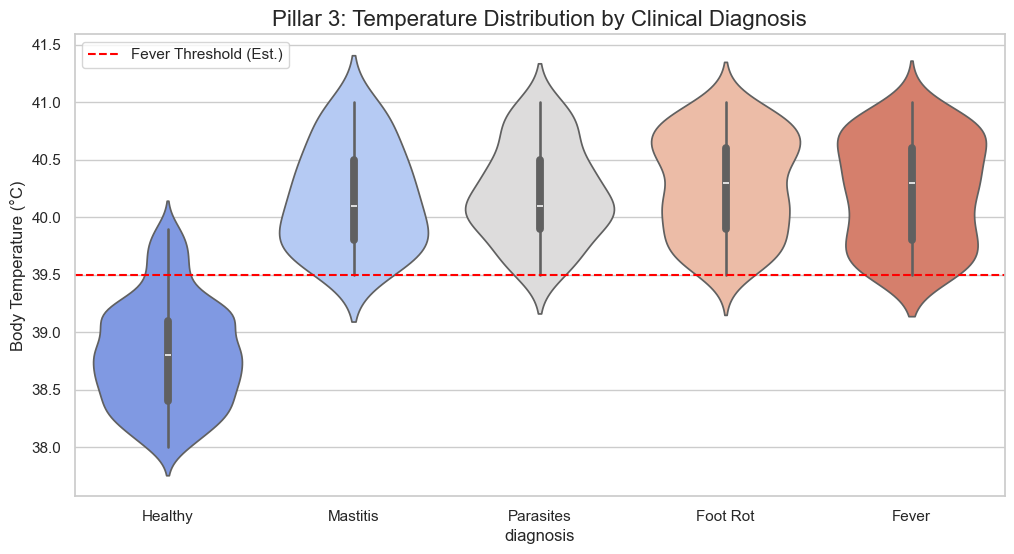

In [ ]:
if 'df_health' in locals():
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df_health, x='diagnosis', y='temp', hue='diagnosis', palette='coolwarm', legend=False)
    plt.axhline(y=39.5, color='red', linestyle='--', label='Fever Threshold (Est.)')
    plt.title('Pillar 3: Temperature Distribution by Clinical Diagnosis')
    plt.ylabel('Body Temperature (°C)')
    plt.legend()
    plt.show()

**Interpretation:**
The 'violin' shapes show the density of temperature readings. A wider top for 'Fever' or 'Mastitis' diagnoses validates that these specific conditions are indeed associated with higher thermal readings. This thermal baseline helps set the threshold for automated alerts in the active monitoring system.